# Fit MOSK GPs to synthetic MOGPs

This notebook describes the use of MOGPTK to fit MOGP models to synthetically generally MOGP data.

In [1]:
import mogptk
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#torch.manual_seed(0);

/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Dataset 1: Two-bands

Seed = 25983

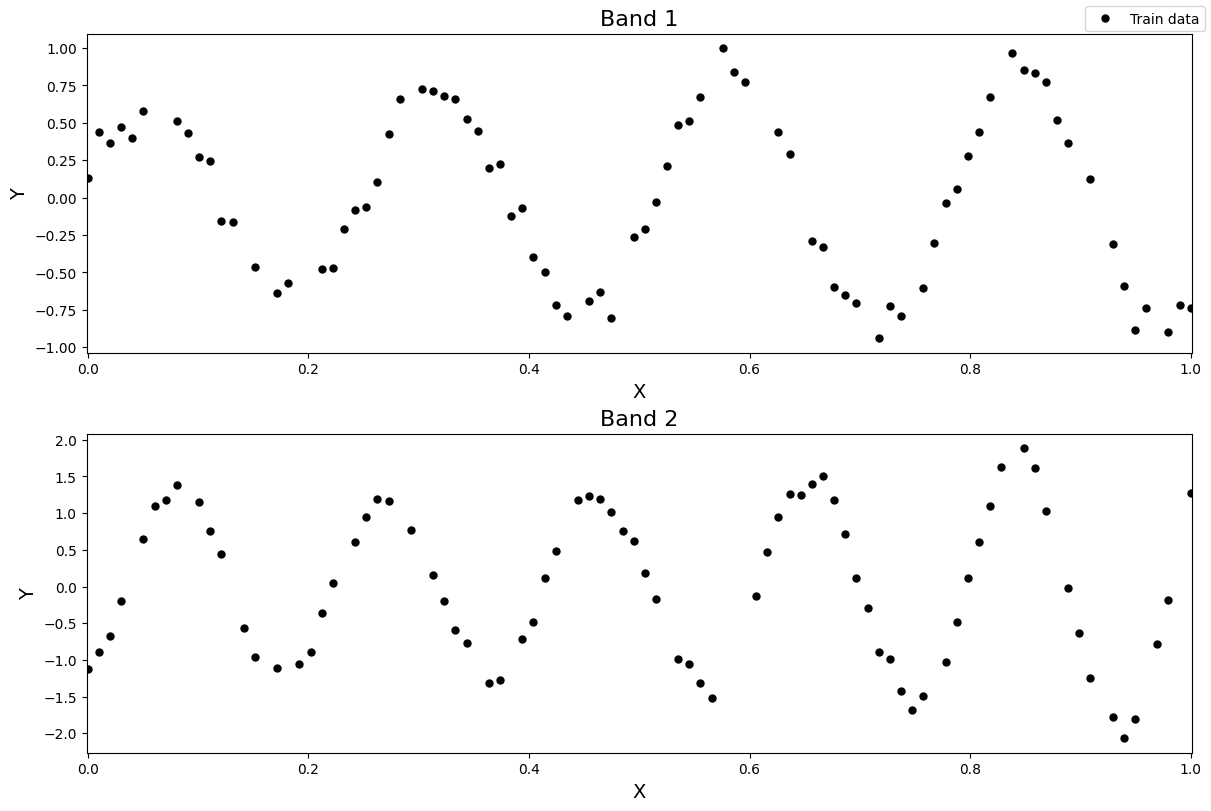

In [11]:
# Known values from synthetic data generated in R
D = 2
Q = 1

seed3444_df = pd.read_csv('data/D2-Q1-seed28027-n100-mcar0.2-sigma0.1-sim.csv')
band1_df = seed3444_df.query('d == 1')
band2_df = seed3444_df.query('d == 2')

dataset1 = mogptk.DataSet(
    mogptk.Data(X=band1_df['t'], Y=band1_df['y'], name='Band 1'),
    mogptk.Data(X=band2_df['t'], Y=band2_df['y'], name='Band 2')
)

dataset1.plot();

### Power Spectrum

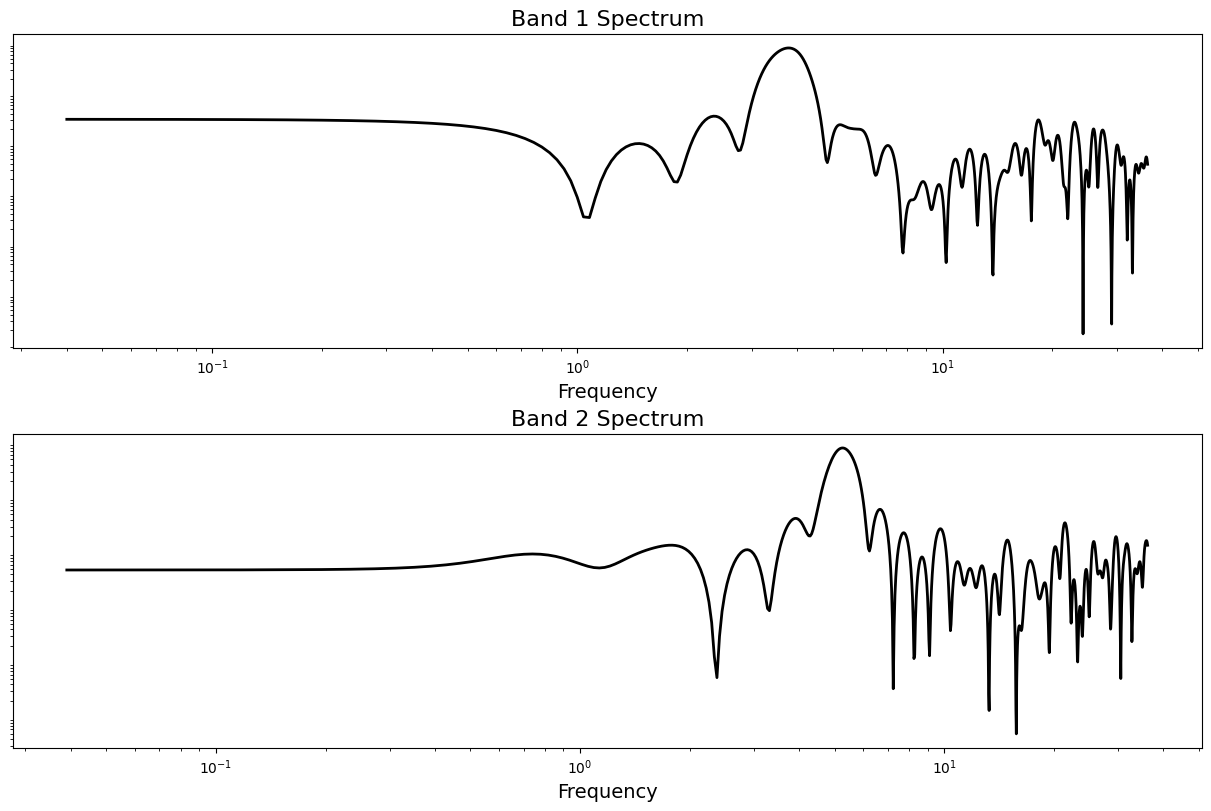

In [12]:
dataset1.plot_spectrum(method='ls', log=True); # Lomb Scargle

### Model 1

In [13]:
model1 = mogptk.MOSM(dataset1, Q=1)
model1.init_parameters(method='LS', iters=500)
model1.print_parameters();

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 7.65944082] [14.25144204]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 49.50000000000063]",[[[3.78712871]] [[5.25742574]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.14287959]] [[0.13186276]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.55268211 1.02874032]


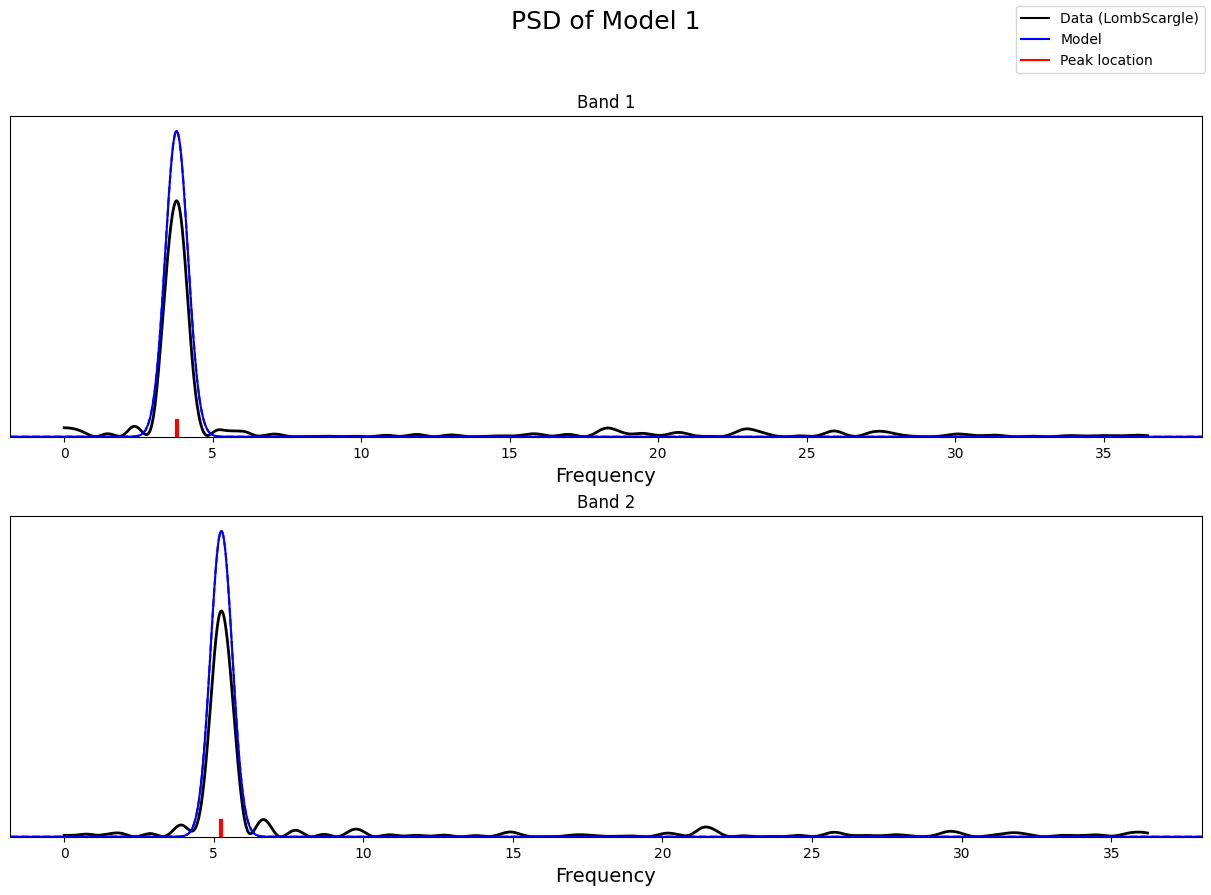

In [14]:
model1.plot_spectrum(title='PSD of Model 1');

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 12
‣ Training points: 160
‣ Iterations: 1000
     0/1000   0:00:00  loss=     130.117  error=   0.0904012 (warmup)
   948/1000   0:00:10  loss=      115.34  error=   0.0775181
  1000/1000   0:00:10  loss=     114.546  error=   0.0775347
Optimization finished in 10.770 seconds


Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 7.13651675] [13.50236217]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 49.50000000000063]",[[[3.76933163]] [[5.49741404]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.12948255]] [[0.1195205 ]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-2.37989973e-26]] [[ 2.37989973e-26]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-5.26069823e-27] [ 5.26069823e-27]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.50140246 0.93516116]


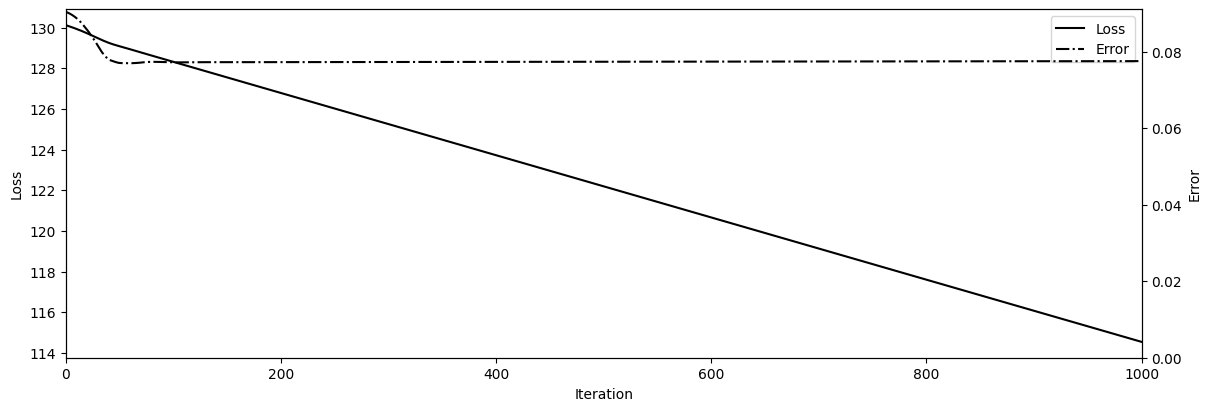

In [15]:
model1.train(method='Adam', iters=1000, plot=True, error='MAE', verbose=True);
model1.print_parameters();

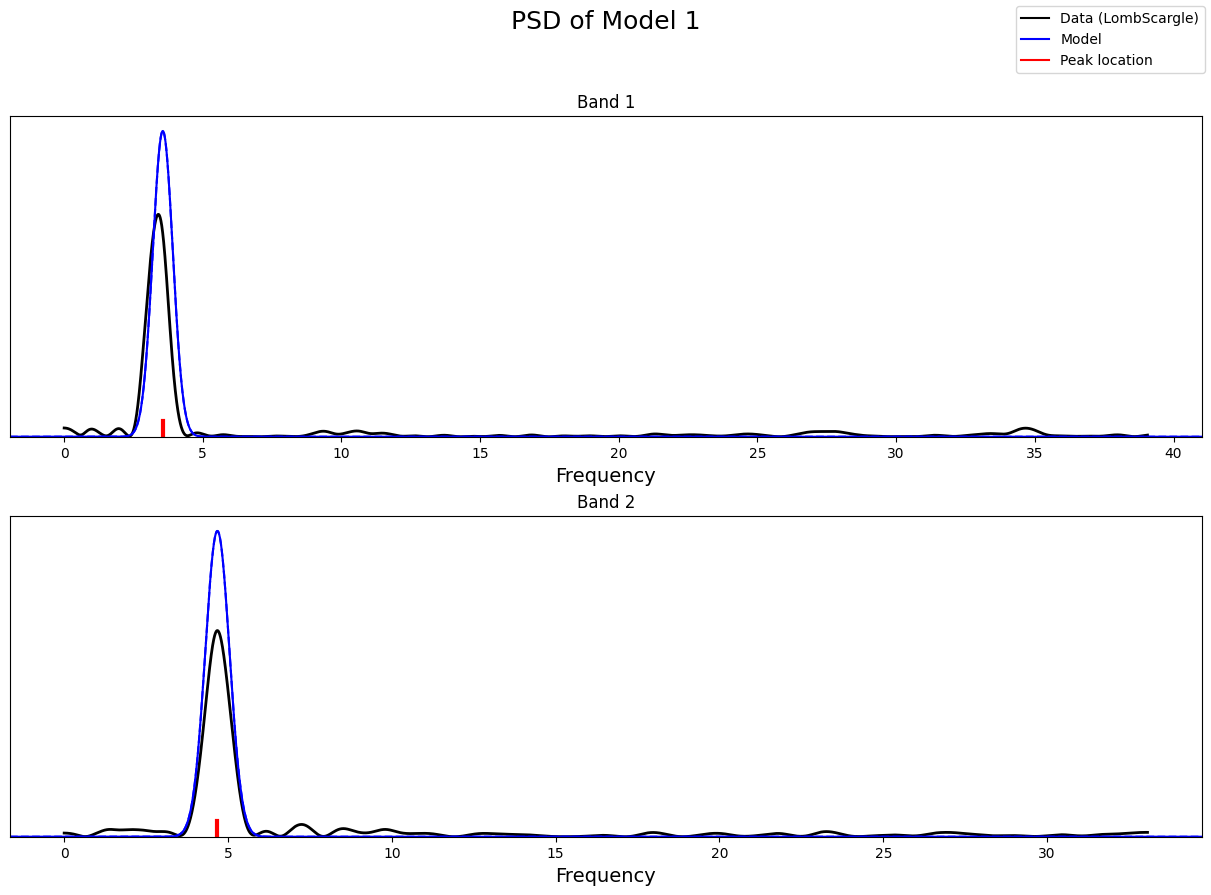

In [8]:
model1.plot_spectrum(title='PSD of Model 1');

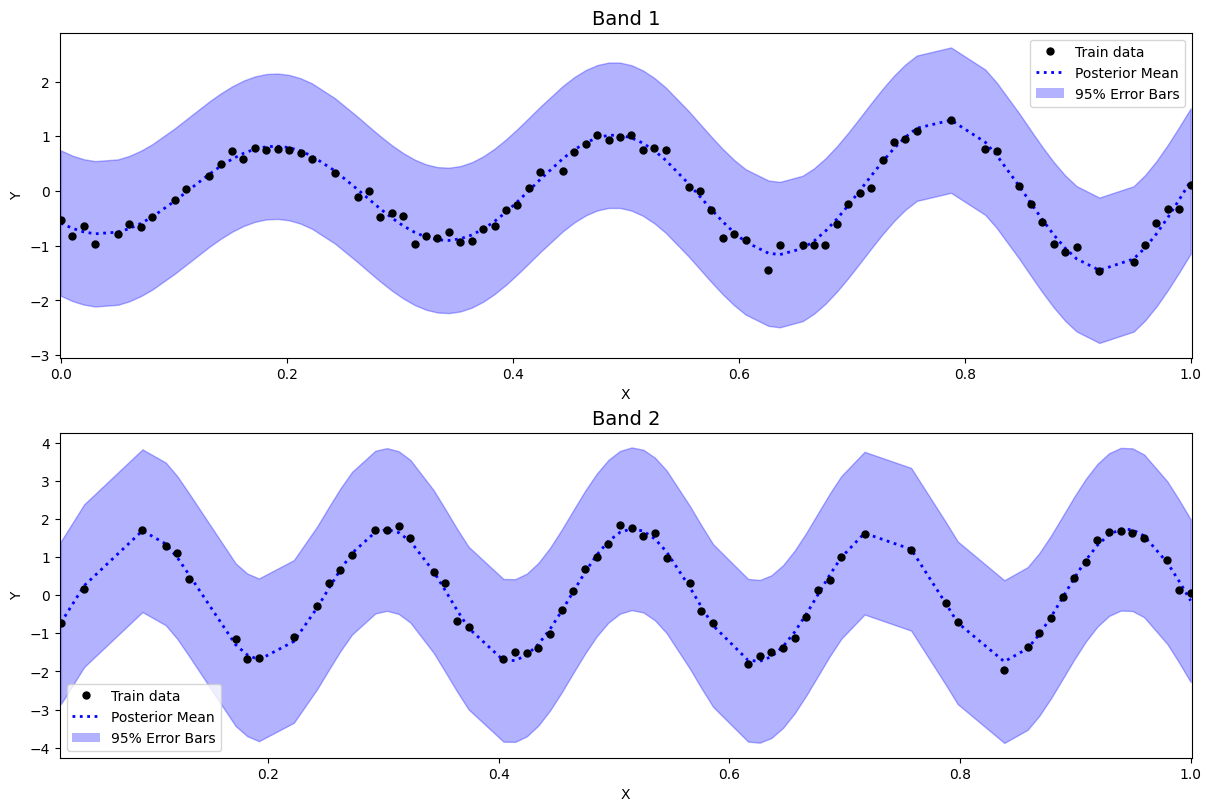

In [9]:
model1.plot_prediction();

In [10]:
model1.print_parameters();

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 9.50840813] [15.82078247]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 49.50000000000077]",[[[3.55982997]] [[4.6788279 ]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.13089924]] [[0.13629436]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-2.58503928e-09]] [[ 2.58503928e-09]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-6.29205206e-10] [ 6.29205206e-10]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.66425737 1.0661931 ]
